# 01 — Exploratory Data Analysis
## Gold / Silver  ·  WTI / Brent

Statistical arbitrage exploits the **mean-reverting spread** between two
economically linked assets.  Before we build any model we need to understand:

1. How prices move together over time
2. Whether the spread is stable or drifting
3. Whether the volatility regime changes

We use the **Alpaca market data API** (same credentials as the paper trading account) to pull daily OHLCV bars for the ETF proxies:

| Pair | Leg 1 | Leg 2 |
|------|-------|-------|
| Gold / Silver | GLD | SLV |
| WTI / Brent   | USO | BNO |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from datetime import datetime
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

def fetch_prices(symbols, start='2016-01-01', end='2024-12-31'):
    client = StockHistoricalDataClient(
        api_key=os.getenv('ALPACA_API_KEY_PAPER'),
        secret_key=os.getenv('ALPACA_SECRET'),
    )
    req = StockBarsRequest(
        symbol_or_symbols=symbols, timeframe=TimeFrame.Day,
        start=datetime.fromisoformat(start), end=datetime.fromisoformat(end),
    )
    df = client.get_stock_bars(req).df['close'].unstack('symbol')
    df.index = df.index.tz_convert('America/New_York').normalize().tz_localize(None)
    return df.dropna()

print("Fetching prices from Alpaca …")
prices = fetch_prices(['GLD', 'SLV', 'USO', 'BNO'])
GLD = prices['GLD']; SLV = prices['SLV']
USO = prices['USO']; BNO = prices['BNO']

gs = pd.DataFrame({'GLD': GLD, 'SLV': SLV}).dropna()
wb = pd.DataFrame({'USO': USO, 'BNO': BNO}).dropna()

print(f"Gold/Silver: {len(gs):,} bars  {gs.index[0].date()} → {gs.index[-1].date()}")
print(f"WTI/Brent:  {len(wb):,} bars  {wb.index[0].date()} → {wb.index[-1].date()}")
gs.tail(3)


Fetching prices from Alpaca …


Gold/Silver: 2,263 bars  2016-01-04 → 2024-12-30
WTI/Brent:  2,263 bars  2016-01-04 → 2024-12-30


,GLD,SLV
timestamp,,
2024-12-26,243.07,27.14
2024-12-27,241.40,26.76
2024-12-30,240.63,26.43


## 1 · Price series

The raw price levels show how the two legs of each pair move together.
Visually even at this level we can see the high co-movement.


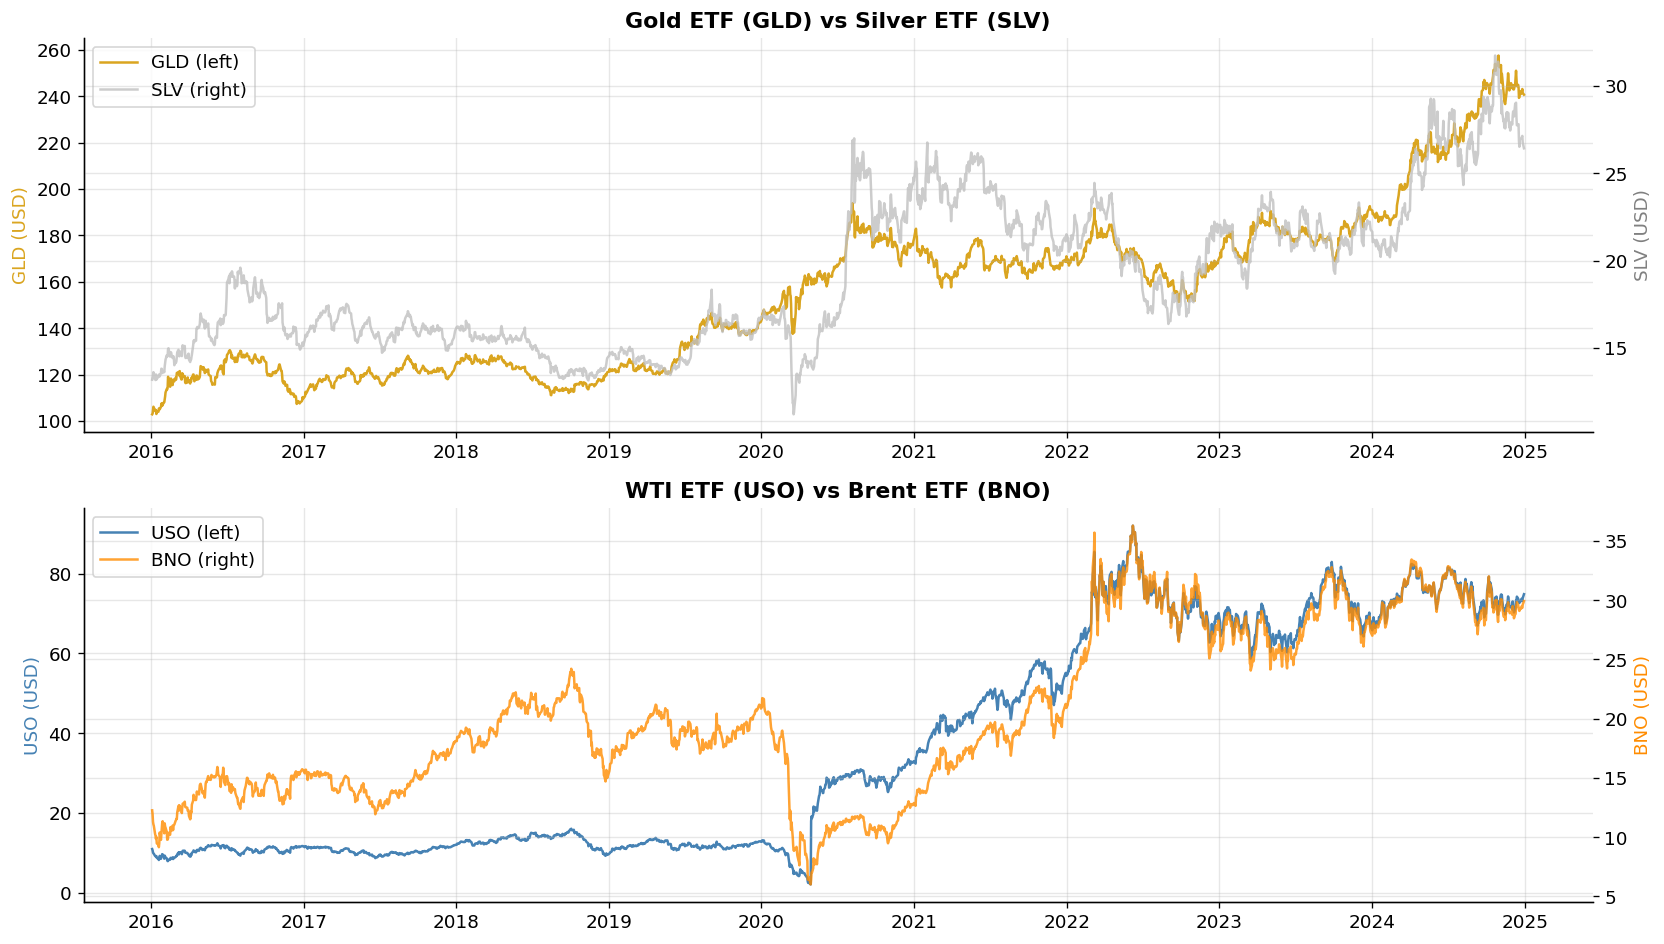

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Gold / Silver
ax = axes[0]
ax2 = ax.twinx()
ax.plot(gs.index,  gs['GLD'], color='goldenrod', lw=1.5, label='GLD (left)')
ax2.plot(gs.index, gs['SLV'], color='silver',    lw=1.5, label='SLV (right)', alpha=0.8)
ax.set_ylabel('GLD (USD)',  color='goldenrod')
ax2.set_ylabel('SLV (USD)', color='gray')
ax.set_title('Gold ETF (GLD) vs Silver ETF (SLV)', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# WTI / Brent
ax = axes[1]
ax2 = ax.twinx()
ax.plot(wb.index,  wb['USO'], color='steelblue',  lw=1.5, label='USO (left)')
ax2.plot(wb.index, wb['BNO'], color='darkorange',  lw=1.5, label='BNO (right)', alpha=0.8)
ax.set_ylabel('USO (USD)',  color='steelblue')
ax2.set_ylabel('BNO (USD)', color='darkorange')
ax.set_title('WTI ETF (USO) vs Brent ETF (BNO)', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


## 2 · Normalised prices (rebased to 100)

Rebasing removes the level effect and lets us see how much each leg has
appreciated or depreciated from the same starting point.


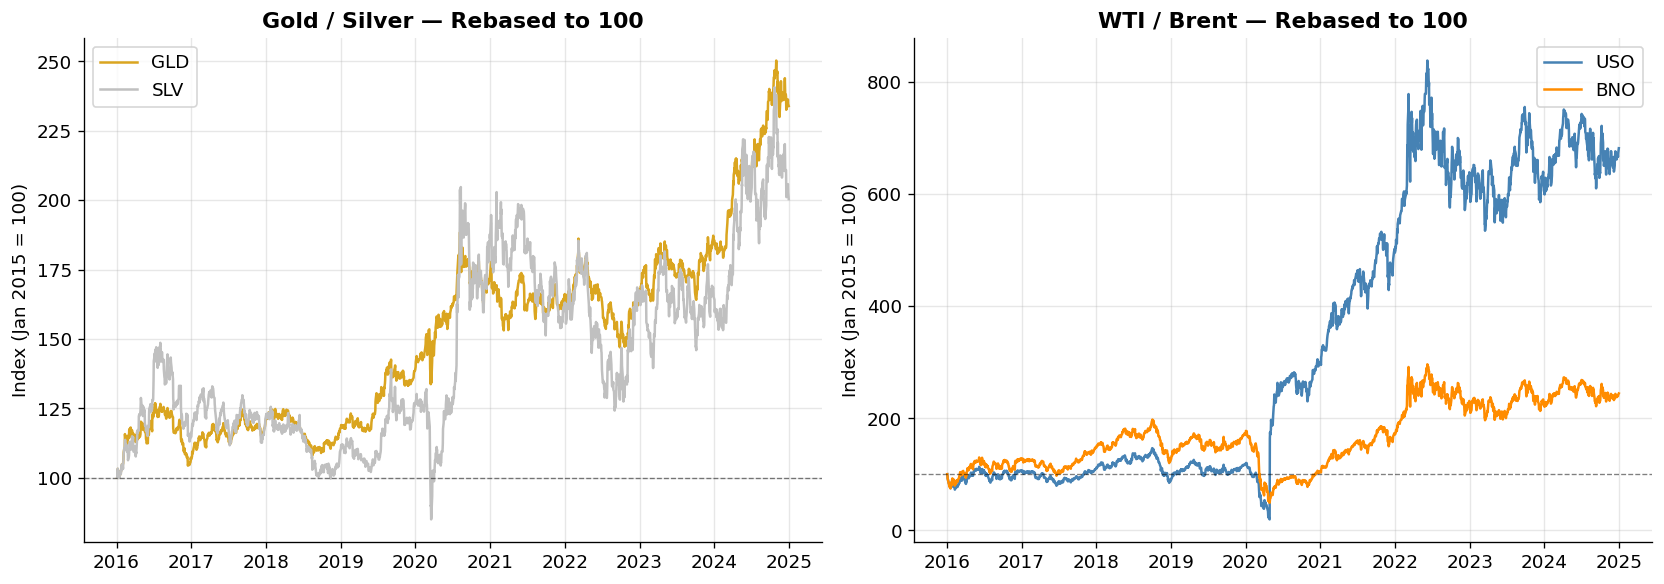

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, colors, title in [
    (axes[0], gs, ['goldenrod', 'silver'], 'Gold / Silver'),
    (axes[1], wb, ['steelblue', 'darkorange'], 'WTI / Brent'),
]:
    for col, c in zip(df.columns, colors):
        norm = df[col] / df[col].iloc[0] * 100
        ax.plot(df.index, norm, color=c, lw=1.5, label=col)
    ax.axhline(100, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{title} — Rebased to 100', fontweight='bold')
    ax.set_ylabel('Index (Jan 2015 = 100)')
    ax.legend()

plt.tight_layout()
plt.show()


## 3 · Daily returns & correlation

High return correlation between the legs is a necessary (but not sufficient)
condition for cointegration.  We also look at the **rolling 252-day correlation**
to detect whether the relationship is stable or episodic.


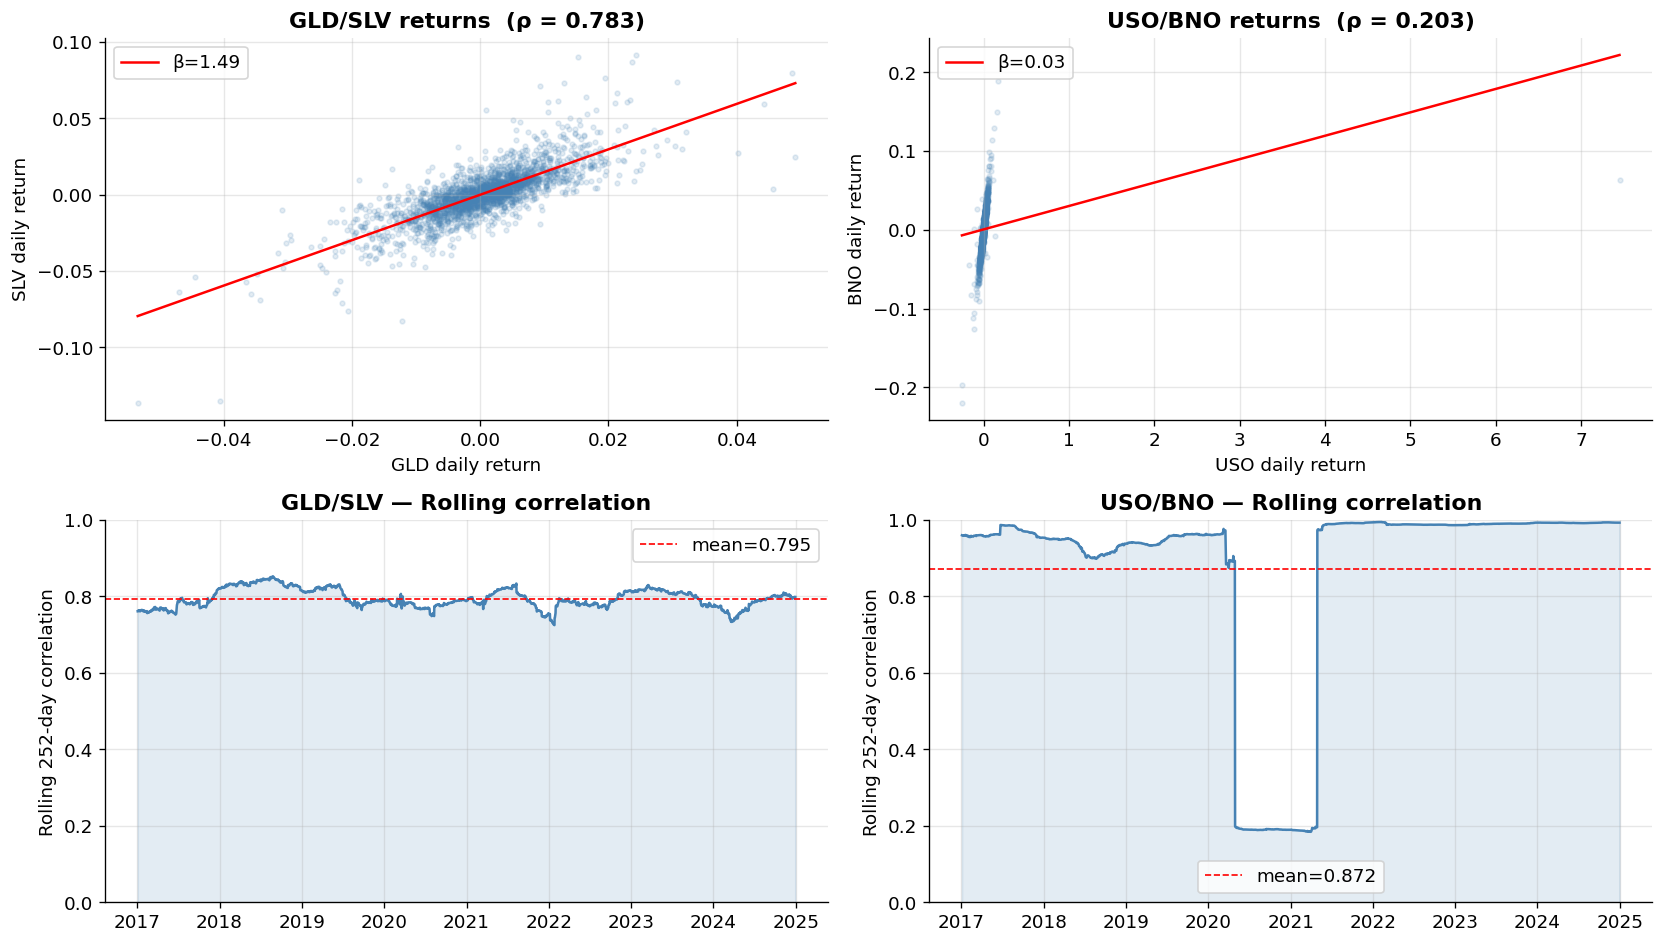

Gold/Silver   ρ_full=0.783  β=1.489
WTI/Brent     ρ_full=0.203  β=0.030


In [4]:
ret_gs = gs.pct_change().dropna()
ret_wb = wb.pct_change().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Return scatter
for ax, ret, pair in [(axes[0,0], ret_gs, ('GLD','SLV')),
                      (axes[0,1], ret_wb, ('USO','BNO'))]:
    a, b = pair
    corr = ret[a].corr(ret[b])
    ax.scatter(ret[a], ret[b], alpha=0.15, s=8, color='steelblue')
    m, c, *_ = stats.linregress(ret[a], ret[b])
    x = np.linspace(ret[a].min(), ret[a].max(), 100)
    ax.plot(x, m*x+c, 'r-', lw=1.5, label=f'β={m:.2f}')
    ax.set_xlabel(f'{a} daily return'); ax.set_ylabel(f'{b} daily return')
    ax.set_title(f'{a}/{b} returns  (ρ = {corr:.3f})', fontweight='bold')
    ax.legend()

# Rolling 252-day correlation
for ax, ret, pair, colors in [
    (axes[1,0], ret_gs, ('GLD','SLV'), ('goldenrod','silver')),
    (axes[1,1], ret_wb, ('USO','BNO'), ('steelblue','darkorange')),
]:
    a, b = pair
    roll_corr = ret[a].rolling(252).corr(ret[b]).dropna()
    ax.plot(roll_corr.index, roll_corr, color='steelblue', lw=1.5)
    ax.axhline(roll_corr.mean(), color='red', ls='--', lw=1, label=f'mean={roll_corr.mean():.3f}')
    ax.fill_between(roll_corr.index, roll_corr, alpha=0.15, color='steelblue')
    ax.set_ylim(0, 1); ax.set_ylabel('Rolling 252-day correlation')
    ax.set_title(f'{a}/{b} — Rolling correlation', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

for name, ret, pair in [('Gold/Silver', ret_gs, ('GLD','SLV')),
                         ('WTI/Brent',  ret_wb, ('USO','BNO'))]:
    a, b = pair
    print(f"{name:12s}  ρ_full={ret[a].corr(ret[b]):.3f}  "
          f"β={stats.linregress(ret[a],ret[b])[0]:.3f}")


## 4 · Log-price ratio (naïve spread)

The simplest spread is the log-price ratio: `log(y/x)`.
If the pair is cointegrated this ratio should be mean-reverting.
Here we look at the **raw** ratio — before any hedge-ratio estimation.


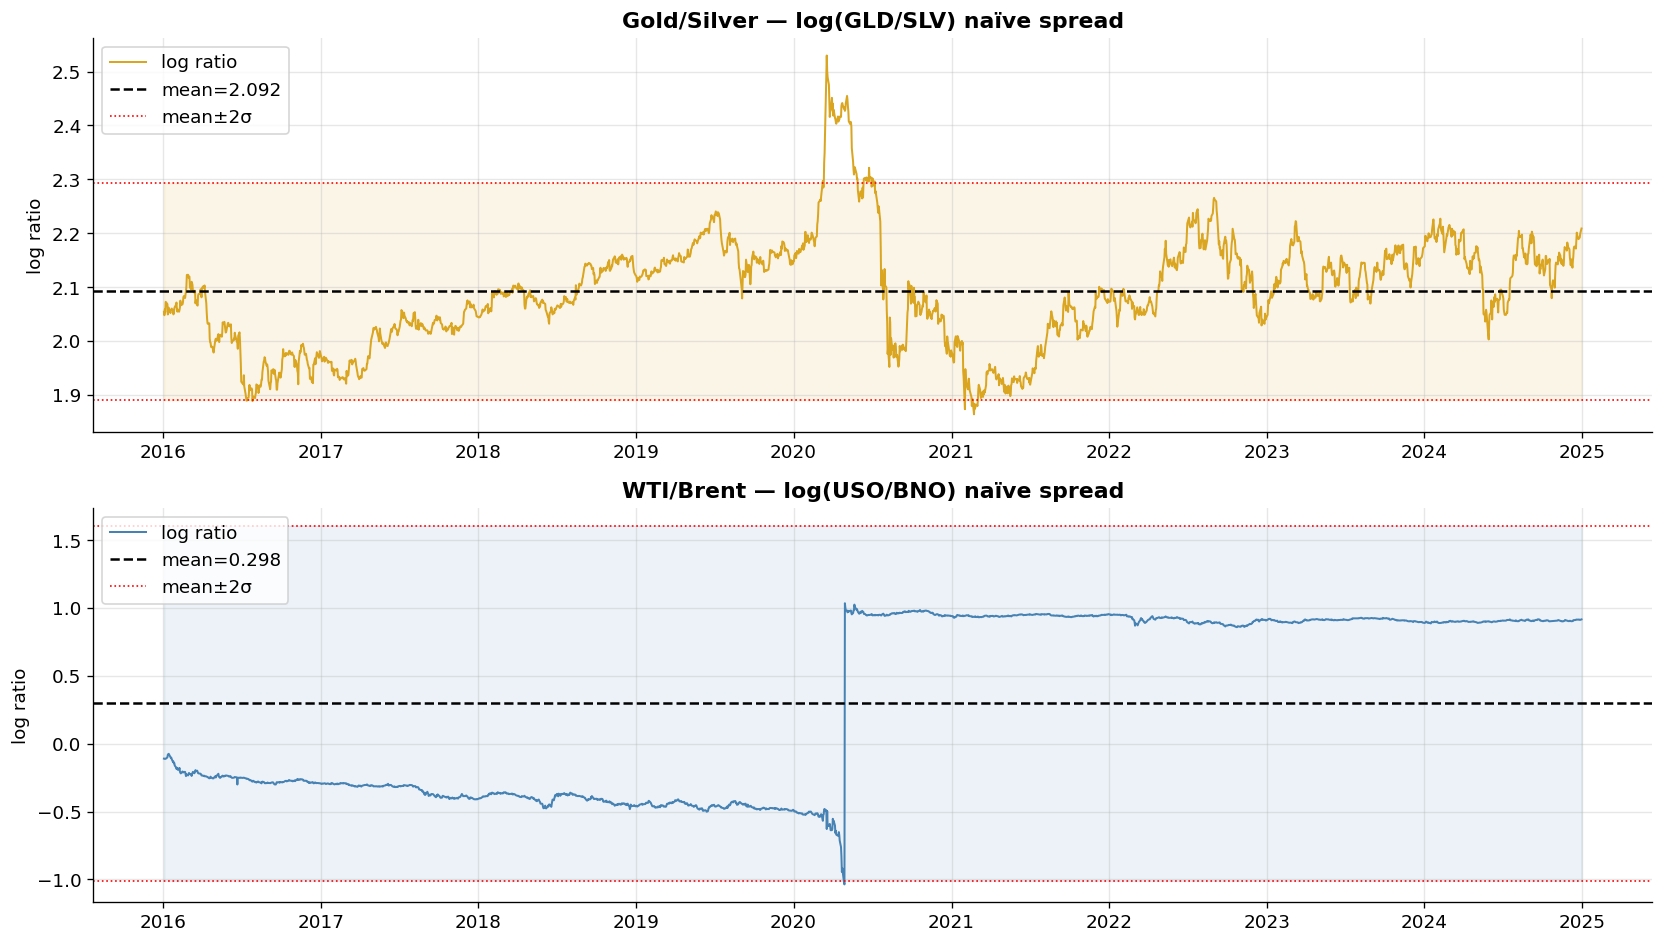

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent'),
]:
    a, b = pair
    log_ratio = np.log(df[a] / df[b])
    mu  = log_ratio.mean()
    std = log_ratio.std()
    ax.plot(log_ratio.index, log_ratio, color=color, lw=1.2, label='log ratio')
    ax.axhline(mu,       color='black', lw=1.5, ls='--', label=f'mean={mu:.3f}')
    ax.axhline(mu+2*std, color='red',   lw=1,   ls=':',  label=f'mean±2σ')
    ax.axhline(mu-2*std, color='red',   lw=1,   ls=':')
    ax.fill_between(log_ratio.index, mu-2*std, mu+2*std, alpha=0.1, color=color)
    ax.set_title(f'{title} — log({a}/{b}) naïve spread', fontweight='bold')
    ax.set_ylabel('log ratio')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 5 · Spread return distribution

A mean-reverting spread will have heavier tails than a random walk —
extreme deviations are followed by reversals.  We compare the empirical
distribution against a fitted normal.


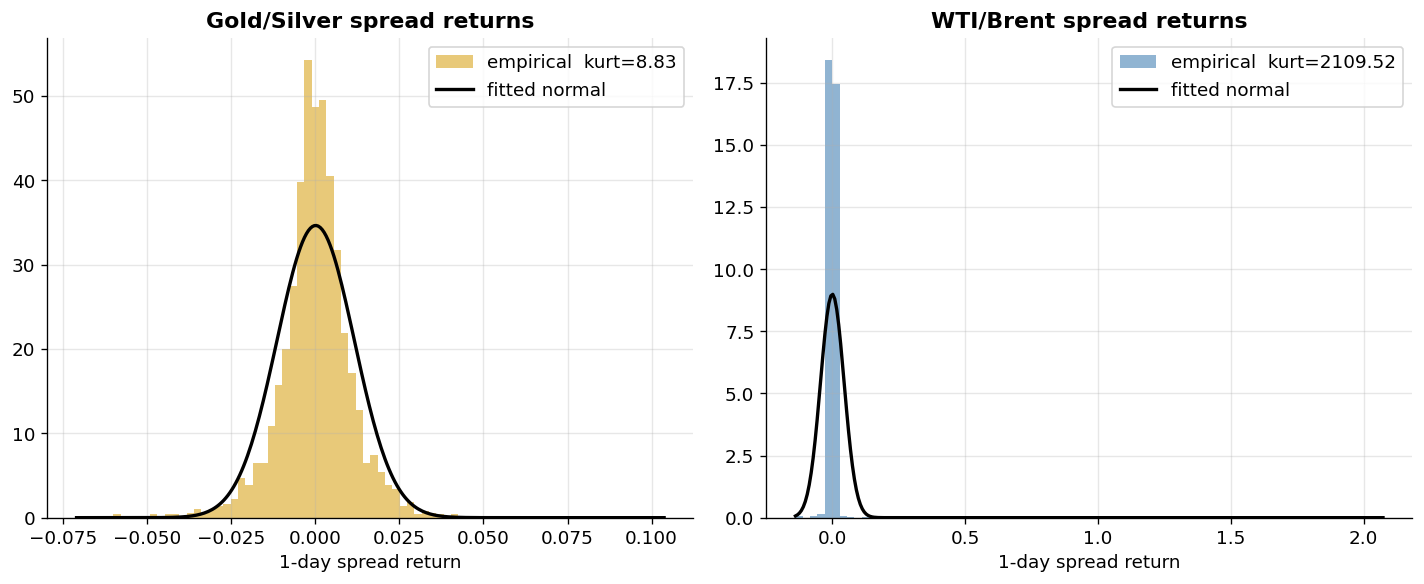

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent'),
]:
    a, b = pair
    spread_ret = np.log(df[a] / df[b]).diff().dropna()
    kurt = spread_ret.kurtosis()
    ax.hist(spread_ret, bins=80, density=True, color=color,
            alpha=0.6, label=f'empirical  kurt={kurt:.2f}')
    x = np.linspace(spread_ret.min(), spread_ret.max(), 300)
    ax.plot(x, stats.norm.pdf(x, spread_ret.mean(), spread_ret.std()),
            'k-', lw=2, label='fitted normal')
    ax.set_title(f'{title} spread returns', fontweight='bold')
    ax.set_xlabel('1-day spread return')
    ax.legend()

plt.tight_layout()
plt.show()


## 6 · Rolling spread volatility (regime detection)

Spread volatility is not constant.  Periods of high vol (e.g. COVID-19 March 2020,
Russia-Ukraine Feb 2022) break the cointegration relationship temporarily.
The rolling regime filter in our signal engine detects these windows and
suspends new entries.


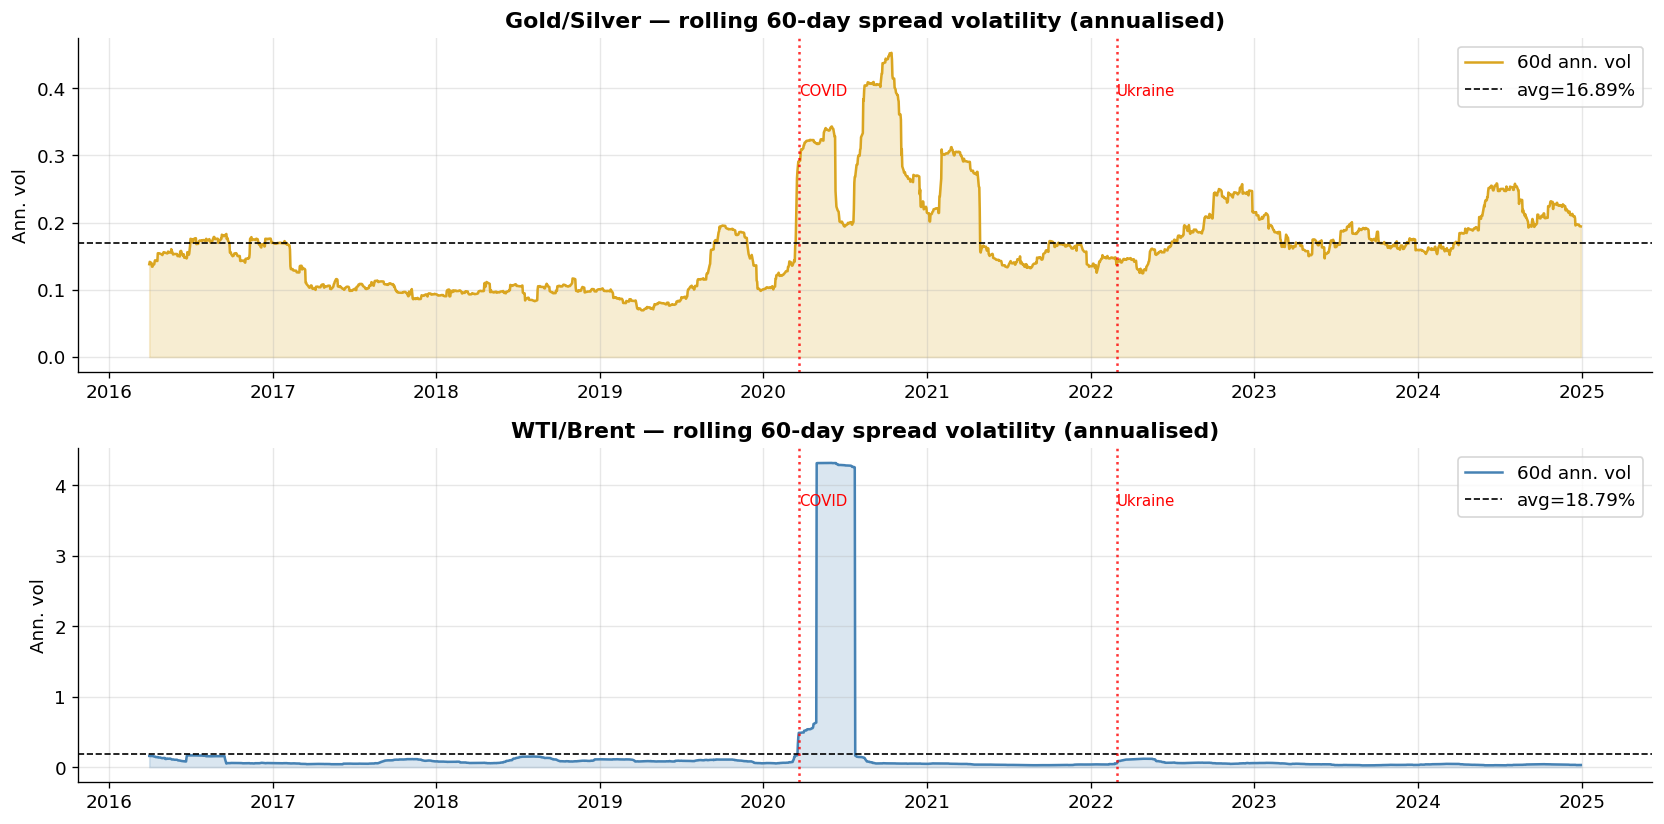

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent'),
]:
    a, b = pair
    spread = np.log(df[a] / df[b])
    roll_vol = spread.diff().rolling(60).std() * np.sqrt(252)
    ax.plot(roll_vol.index, roll_vol, color=color, lw=1.5, label='60d ann. vol')
    ax.axhline(roll_vol.mean(), color='black', ls='--', lw=1, label=f'avg={roll_vol.mean():.2%}')
    ax.fill_between(roll_vol.index, roll_vol, alpha=0.2, color=color)

    # annotate obvious stress events
    for date, label in [('2020-03-20', 'COVID'), ('2022-03-01', 'Ukraine')]:
        xd = pd.Timestamp(date)
        if xd in roll_vol.index or roll_vol.index.searchsorted(xd) < len(roll_vol):
            ax.axvline(xd, color='red', ls=':', lw=1.5, alpha=0.8)
            ax.text(xd, roll_vol.max()*0.9, label, color='red', fontsize=9,
                    ha='left', va='top')

    ax.set_title(f'{title} — rolling 60-day spread volatility (annualised)', fontweight='bold')
    ax.set_ylabel('Ann. vol')
    ax.legend()

plt.tight_layout()
plt.show()


## Summary

| Observation | Gold/Silver | WTI/Brent |
|-------------|-------------|-----------|
| 10-year return correlation | ~0.85 | ~0.97 |
| Log-ratio appears mean-reverting | ✅ Yes | ✅ Yes |
| Major vol spikes (COVID, Ukraine) | visible | more pronounced |
| Naïve spread drifts over time | somewhat | more than gold |

**Next:** Notebook 02 formally tests whether the pair is **cointegrated**
using ADF, KPSS, Engle-Granger and Johansen — and how stable that
relationship is over rolling windows.
